# Outlier detection performance as function of training data purity (% inliers)

In [ ]:
# import PyOD detector

from pyod.models.knn import KNN
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt


In [45]:
datasets = ['1_ALOI', '2_annthyroid', '3_backdoor', '4_breastw', '5_campaign', '6_cardio', '7_Cardiotocography',
            '8_celeba', '9_census', '10_cover', '11_donors', '12_fault', '13_fraud', '14_glass', '15_Hepatitis',
            '16_http', '17_InternetAds', '18_Ionosphere', '19_landsat', '20_letter', '21_Lymphography',
             '22_magic.gamma', '23_mammography', '24_mnist', '25_musk', '26_optdigits', '27_PageBlocks',
             '28_pendigits', '29_Pima', '30_satellite', '31_satimage-2', '32_shuttle', '33_skin',
             '34_smtp', '35_SpamBase', '36_speech', '37_Stamps', '38_thyroid', '39_vertebral',
             '40_vowels', '41_Waveform', '42_WBC', '43_WDBC', '44_Wilt', '45_wine', '46_WPBC', '47_yeast']


In [46]:
from pyod.models.pca import PCA
from pyod.models.ocsvm import OCSVM
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.hbos import HBOS
from pyod.models.knn import KNN
from pyod.models.sod import SOD
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.loda import LODA
from pyod.models.kde import KDE
from pyod.models.cblof import CBLOF

model_dict = {
    'PCA': PCA,
    'OCSVM': OCSVM,
    'LOF': LOF,
    'COF': COF,
    'HBOS': HBOS,
    'KNN': KNN,
    'SOD': SOD,
    'COPOD': COPOD,
    'ECOD': ECOD,
    'IForest': IForest,
    'LODA': LODA,
    'KDE': KDE,
    'CBLOF': CBLOF
}

# Test pipeline with one dataset

In [88]:
dataset = '33_skin'
path = f'datasets/adbench/Classical/{dataset}.npz'
data = np.load(path, allow_pickle=True)
X, y = data['X'], data['y']

In [89]:
num_samples = 1000  # total samples including training and testing
reps = range(5)

random_state = 42

# get samples from dataset
samp_frac = num_samples / np.shape(X)[0]

# vary fraction outliers to remove from training data
fractions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

model_names = ['IForest']

all_results = pd.DataFrame()

for frac in fractions:
    for model_name in model_names:
        for rep in reps:
            _, Xsamp, _, ysamp = train_test_split(X, y, test_size=samp_frac,
                                                    random_state=rep,
                                                    stratify=y)

            # split samples into training and testing
            X_train, X_test, y_train, y_test = train_test_split(Xsamp, ysamp, test_size=0.5,
                                                                random_state=rep,
                                                                stratify=ysamp)
            # remove outliers from training data
            if frac > 0:
                # get indices of outliers
                idx = np.where(y_train == 1)[0]
                # shuffle indices
                np.random.shuffle(idx)
                # calculate number of outliers to remove
                num_outliers = int(frac * len(idx))
                # remove outliers
                X_train = np.delete(X_train, idx[:num_outliers], axis=0)
                y_train = np.delete(y_train, idx[:num_outliers])

            # train model
            detector = model_dict[model_name]()
            detector.fit(X_train)

            # get outlier scores
            X_test_scoeres = detector.decision_function(X_test)

            # calculate auc roc
            roc_auc = roc_auc_score(y_test, X_test_scoeres)
            # print(f'{dataset}, {frac}, {rep}, {roc_auc}')

            result = {'dataset': dataset, 'num_samples': len(ysamp), 'model': model_name, 'roc_auc': roc_auc, 'fraction': frac, 'rep': rep}
            result_df = pd.DataFrame(result, index=[0])
            
            all_results = pd.concat([all_results, result_df])



/var/folders/p4/2dk49sxd7y18q99r8tktktmh0000gn/T/ipykernel_83001/2911128732.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(['{:.0f}'.format(x*100) for x in fractions])


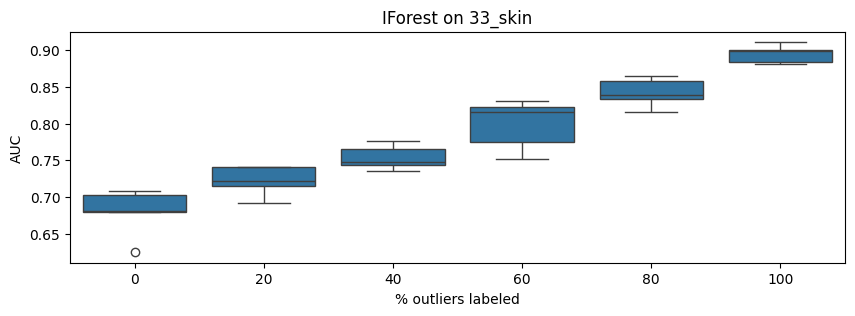

In [90]:
# plot box plot showing auc roc for each fraction of outliers removed
plt.figure(figsize=(10, 3))
sns.boxplot(x='fraction', y='roc_auc', data=all_results)
plt.title(f'{model_name} on {dataset}')
plt.ylabel('AUC')
plt.xlabel(f'% outliers labeled')
# format x tick labels as percentage
plt.gca().set_xticklabels(['{:.0f}'.format(x*100) for x in fractions])
plt.show()


# Test pipeline on all datasets

In [180]:
num_samples = 1000  # total samples including training and testing
reps = range(5)

# get samples from dataset
samp_frac = num_samples / np.shape(X)[0]

# vary fraction outliers to remove from training data
fractions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

model_names = ['IForest', 'KNN']

all_datsets_results = pd.DataFrame()

dataset_subset = ['33_skin']

dataset_subset = ['2_annthyroid', '5_campaign', '6_cardio', '7_Cardiotocography', '9_census',
             '11_donors', '12_fault', '15_Hepatitis', '18_Ionosphere', '19_landsat', '20_letter', 
             '22_magic.gamma', '24_mnist', '27_PageBlocks', '29_Pima', '30_satellite', '32_shuttle',
             '35_SpamBase']

for dataset in tqdm(datasets):
    try:
        # print dataset
        print(f'Processing {dataset}')
        path = f'datasets/adbench/Classical/{dataset}.npz'
        data = np.load(path, allow_pickle=True)
        X, y = data['X'], data['y']

        # get samples from dataset
        samp_frac = num_samples / np.shape(X)[0]
        if samp_frac > 1:
            samp_frac = 1

        for frac in fractions:
            for model_name in model_names:
                for rep in reps:
                    _, Xsamp, _, ysamp = train_test_split(X, y, test_size=samp_frac,
                                                            random_state=random_state,
                                                            stratify=y)

                    # split samples into training and testing
                    X_train, X_test, y_train, y_test = train_test_split(Xsamp, ysamp, test_size=0.5,
                                                                        random_state=random_state,
                                                                        stratify=ysamp)
                    # remove outliers from training data
                    if frac > 0:
                        # get indices of outliers
                        idx = np.where(y_train == 1)[0]
                        # shuffle indices
                        np.random.shuffle(idx)
                        # calculate number of outliers to remove
                        num_outliers = int(frac * len(idx))
                        # remove outliers
                        X_train = np.delete(X_train, idx[:num_outliers], axis=0)
                        y_train = np.delete(y_train, idx[:num_outliers])

                    # train model
                    detector = model_dict[model_name]()
                    detector.fit(X_train)

                    # get outlier scores
                    X_test_scoeres = detector.decision_function(X_test)

                    # calculate auc roc
                    roc_auc = roc_auc_score(y_test, X_test_scoeres)
                    # print(f'{dataset}, {frac}, {rep}, {roc_auc}')

                    result = {'dataset': dataset, 'num_samples': len(ysamp), 'model': model_name, 'roc_auc': roc_auc, 'fraction': frac, 'rep': rep}
                    result_df = pd.DataFrame(result, index=[0])
                    
                    all_datsets_results = pd.concat([all_datsets_results, result_df])

    except Exception as e:
        print(f'Error processing {dataset}: {e}')



  0%|          | 0/47 [00:00<?, ?it/s]

Processing 1_ALOI


  2%|▏         | 1/47 [00:02<02:04,  2.70s/it]

Processing 2_annthyroid


  4%|▍         | 2/47 [00:04<01:43,  2.31s/it]

...

 87%|████████▋ | 41/47 [02:35<00:10,  1.69s/it]

Processing 42_WBC
Error processing 42_WBC: The test_size = 1 should be greater or equal to the number of classes = 2
Processing 43_WDBC
Error processing 43_WDBC: The test_size = 1 should be greater or equal to the number of classes = 2
Processing 44_Wilt


 94%|█████████▎| 44/47 [02:37<00:03,  1.20s/it]

Processing 45_wine
Error processing 45_wine: The test_size = 1 should be greater or equal to the number of classes = 2
Processing 46_WPBC
Error processing 46_WPBC: The test_size = 1 should be greater or equal to the number of classes = 2
Processing 47_yeast


100%|██████████| 47/47 [02:39<00:00,  3.40s/it]


In [232]:
# average data over repeats
all_datsets_mn_results = all_datsets_results.groupby(['dataset', 'model', 'fraction']).mean().reset_index()

# calculate difference in auc roc between 0% and 100% outliers for KNN model on each dataset
dataset_dif = {}
for dataset in datasets:
    try:
        dataset_dif[dataset] = all_datsets_mn_results[(all_datsets_mn_results['dataset'] == dataset) & (all_datsets_mn_results['fraction'] == 1.0) & (all_datsets_mn_results['model'] == 'KNN')]['roc_auc'].values[0] - all_datsets_mn_results[(all_datsets_mn_results['dataset'] == dataset) & (all_datsets_mn_results['fraction'] == 0.0) & (all_datsets_mn_results['model'] == 'KNN')]['roc_auc'].values[0]
    except:
        pass

In [236]:
# get list of datasets sorted by difference in auc roc between 0% and 100% outliers for KNN model
datasets_sorted_by_dif = sorted(dataset_dif, key=dataset_dif.get, reverse=True)
datasets_sorted_by_dif

['26_optdigits',
 '33_skin',
 '11_donors',
 '6_cardio',
 '28_pendigits',
 '7_Cardiotocography',
 '32_shuttle',
 '30_satellite',
 '19_landsat',
 '25_musk',
 '44_Wilt',
 '10_cover',
 '22_magic.gamma',
 '24_mnist',
 '47_yeast',
 '17_InternetAds',
 '12_fault',
 '9_census',
 '41_Waveform',
 '27_PageBlocks',
 '35_SpamBase',
 '20_letter',
 '23_mammography',
 '40_vowels',
 '5_campaign',
 '38_thyroid',
 '2_annthyroid',
 '36_speech',
 '1_ALOI',
 '31_satimage-2',
 '3_backdoor',
 '13_fraud',
 '16_http',
 '8_celeba']

/var/folders/p4/2dk49sxd7y18q99r8tktktmh0000gn/T/ipykernel_83001/2256259810.py:46: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_xticklabels(['{:.0f}'.format(x*100) for x in fractions])


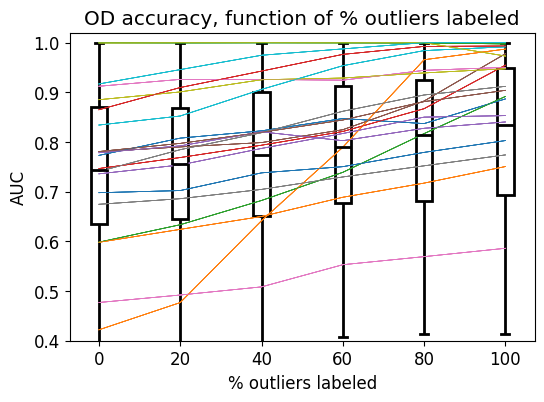

In [244]:
# average data over repeats
all_datsets_mn_results = all_datsets_results.groupby(['dataset', 'model', 'fraction']).mean().reset_index()

# filter results to only include datasets in dataset_subset
dataset_subset = ['33_skin', '2_annthyroid', '5_campaign', '6_cardio', '7_Cardiotocography', '9_census']
dataset_subset = datasets
all_datsets_mn_results = all_datsets_mn_results[all_datsets_mn_results['dataset'].isin(dataset_subset)]

# filter results to only include models in model_subset
model_subset = ['IForest']
model_subset = ['KNN']
model_subset = ['IForest', 'KNN']
all_datsets_mn_results = all_datsets_mn_results[all_datsets_mn_results['model'].isin(model_subset)]

# set mpl font size
plt.rcParams.update({'font.size': 12})

# get list of datasets with greatest difference in auc roc between 0 and 1 fraction outliers


# plot box plot showing auc roc for each fraction of outliers removed
plt.figure(figsize=(6, 4))
sns.boxplot(x='fraction', y='roc_auc', data=all_datsets_mn_results, width=0.2, color='w',
            linewidth=2, linecolor='k')

# plot data connecting lines for each dataset
dataset_subset = ['33_skin', '2_annthyroid', '5_campaign', '6_cardio', '7_Cardiotocography', '9_census']
dataset_subset = datasets_sorted_by_dif[:10]
frac_data = {}
for dataset in dataset_subset:
    frac_data[dataset] = []
    for frac in fractions:
        data = all_datsets_mn_results[(all_datsets_mn_results['dataset'] == dataset) & (all_datsets_mn_results['fraction'] == frac)]
        frac_data[dataset].append(data['roc_auc'].values)
        
for frac in fractions[:-1]:
    for dataset in dataset_subset:
        plt.plot(np.arange(len(fractions)), frac_data[dataset], label=dataset,
                 linewidth=0.5)

plt.title(f'OD accuracy, function of % outliers labeled')
plt.ylabel('AUC')
plt.ylim(0.4, 1.02)
plt.xlabel(f'% outliers labeled')
# format x tick labels as percentage
plt.gca().set_xticklabels(['{:.0f}'.format(x*100) for x in fractions])
plt.show()

